# EDA — Data Science Job Salaries
> Exploratory Data Analysis on real-world DS salary data to uncover insights about roles, experience, and remote work.

### Phase 0 — Setup
> Load libraries and configure global plot settings.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

### Phase 1 — Raw Data Exploration
> Understand the dataset before touching anything. Read it like a detective.

In [13]:
df = pd.read_csv("../data/ds_salaries.csv")
print("Shape", df.shape)
df.head()

Shape (607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [11]:
import os
print(os.getcwd())

d:\Data_Science\01_Practice\06_EDA\03_Ds_Salaries\notebook


In [14]:
df.dtypes

Unnamed: 0             int64
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [15]:
df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [16]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


### Phase 2 — Data Cleaning & Type Fixing
> Protect raw data, drop irrelevant columns, fix dtypes.

In [23]:
clean_df = df.copy()

In [24]:
clean_df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [25]:
clean_df.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [26]:
clean_df.drop(columns=["Unnamed: 0", "salary", "salary_currency"], inplace=True)

cat_cols = ["experience_level", "employment_type", "job_title", "company_location", "company_size"]

clean_df[cat_cols] = clean_df[cat_cols].astype("category")
print(clean_df.shape[1])
clean_df.dtypes

9


work_year                int64
experience_level      category
employment_type       category
job_title             category
salary_in_usd            int64
employee_residence      object
remote_ratio             int64
company_location      category
company_size          category
dtype: object

In [22]:
df.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [27]:
clean_df["employee_residence"] = clean_df["employee_residence"].astype("category")

In [28]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   work_year           607 non-null    int64   
 1   experience_level    607 non-null    category
 2   employment_type     607 non-null    category
 3   job_title           607 non-null    category
 4   salary_in_usd       607 non-null    int64   
 5   employee_residence  607 non-null    category
 6   remote_ratio        607 non-null    int64   
 7   company_location    607 non-null    category
 8   company_size        607 non-null    category
dtypes: category(6), int64(3)
memory usage: 25.8 KB


In [29]:
clean_df.to_csv("../data/clean_ds_salaries.csv", index=False)

### Phase 3 — Univariate Analysis
> Understand each column individually. What does this distribution tell me?

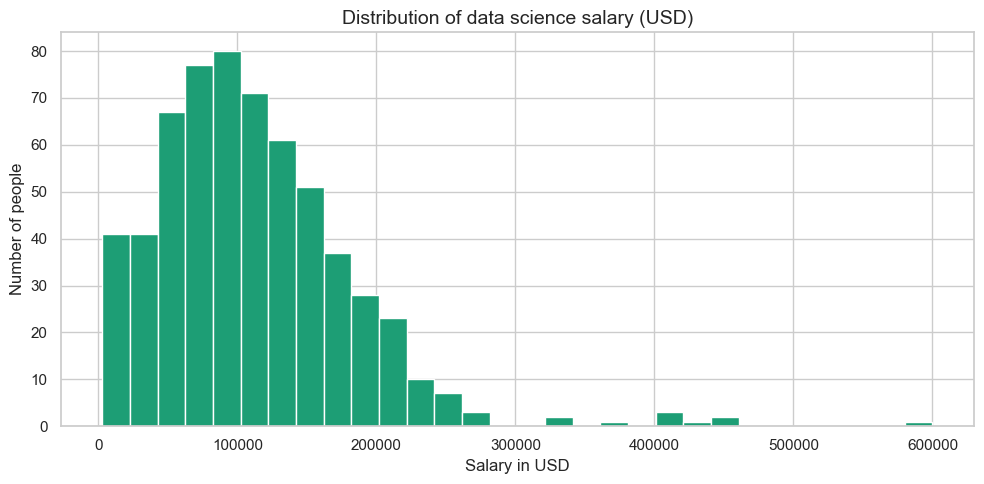

In [32]:
fig, ax = plt.subplots(figsize= (10,5))

ax.hist(clean_df["salary_in_usd"], bins=30, color="#1D9E75", edgecolor="white")
ax.set_title("Distribution of data science salary (USD)")
ax.set_xlabel("Salary in USD")
ax.set_ylabel("Number of people")

plt.tight_layout()
plt.show()

In [33]:
print("Mean Salary", round(clean_df["salary_in_usd"].mean()))
print("Median Salary", round(clean_df["salary_in_usd"].median()))
print("Difference", round(clean_df["salary_in_usd"].mean())-round(clean_df["salary_in_usd"].median()))

Mean Salary 112298
Median Salary 101570
Difference 10728


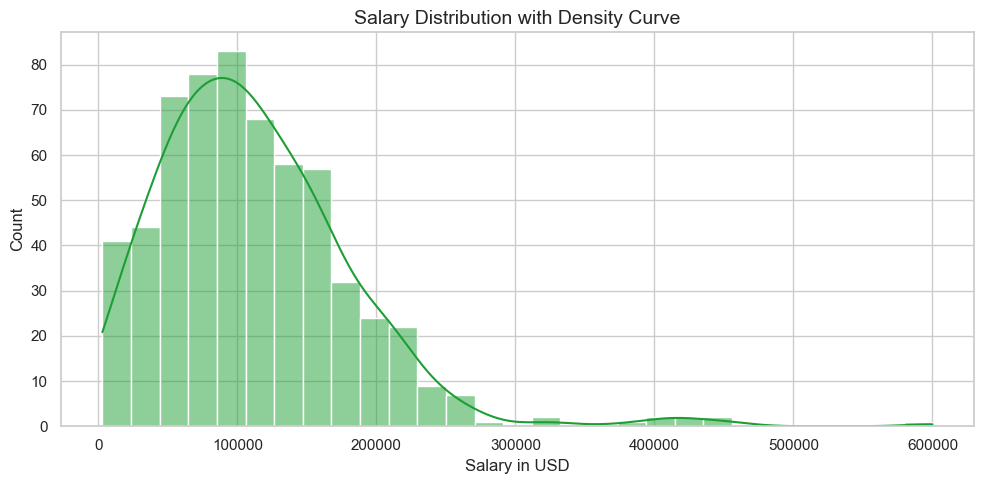

In [37]:
fig, ax = plt.subplots(figsize = (10,5))
sns.histplot(clean_df["salary_in_usd"], kde=True, ax=ax, color="#1D9E35")
ax.set_title("Salary Distribution with Density Curve")
ax.set_xlabel("Salary in USD")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

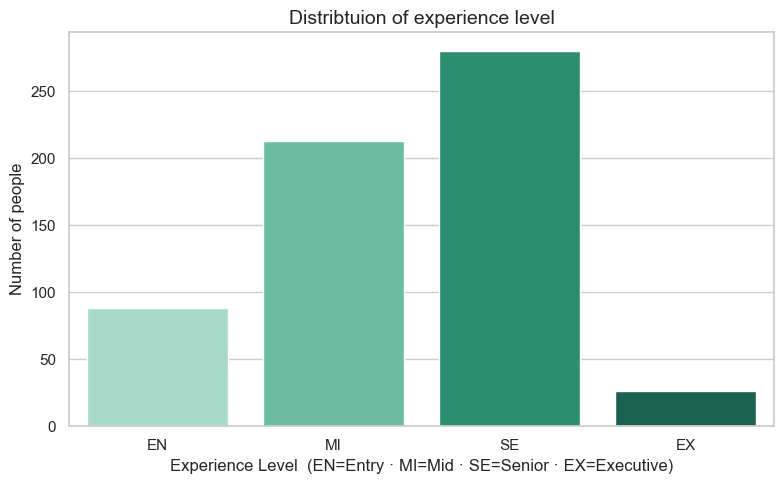

In [38]:
fig, ax = plt.subplots(figsize = (8,5))
sns.countplot(
    data=clean_df, x= "experience_level",
    order=["EN", "MI", "SE", "EX"],
    palette=["#9FE1CB", "#5DCAA5", "#1D9E75", "#0F6E56"],
    ax=ax
)

ax.set_title("Distribtuion of experience level")
ax.set_xlabel("Experience Level  (EN=Entry · MI=Mid · SE=Senior · EX=Executive)")
ax.set_ylabel("Number of people")

plt.tight_layout()
plt.show()

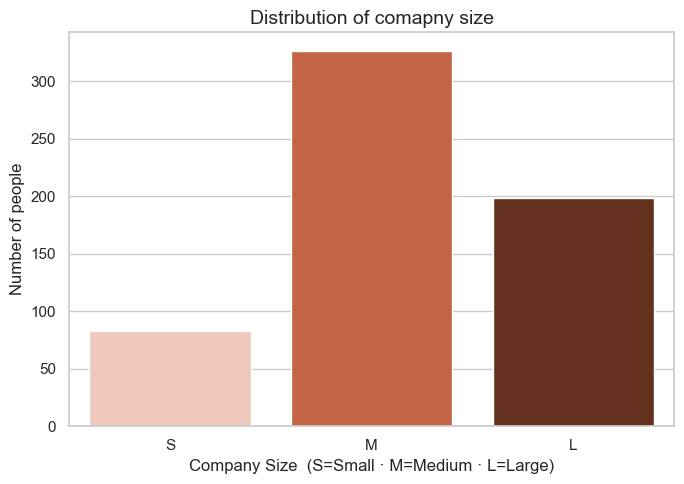

In [39]:
fig, ax = plt.subplots(figsize = (7,5))
sns.countplot(
    data=clean_df, x="company_size",
    order=["S", "M", "L"], 
    palette=["#F5C4B3", "#D85A30", "#712B13"],
    ax=ax
)

ax.set_title("Distribution of comapny size")
ax.set_xlabel("Company Size  (S=Small · M=Medium · L=Large)")
ax.set_ylabel("Number of people")

plt.tight_layout()
plt.show()

### Phase 4 — Bivariate Analysis
> Find relationships between columns. Does X affect Y?

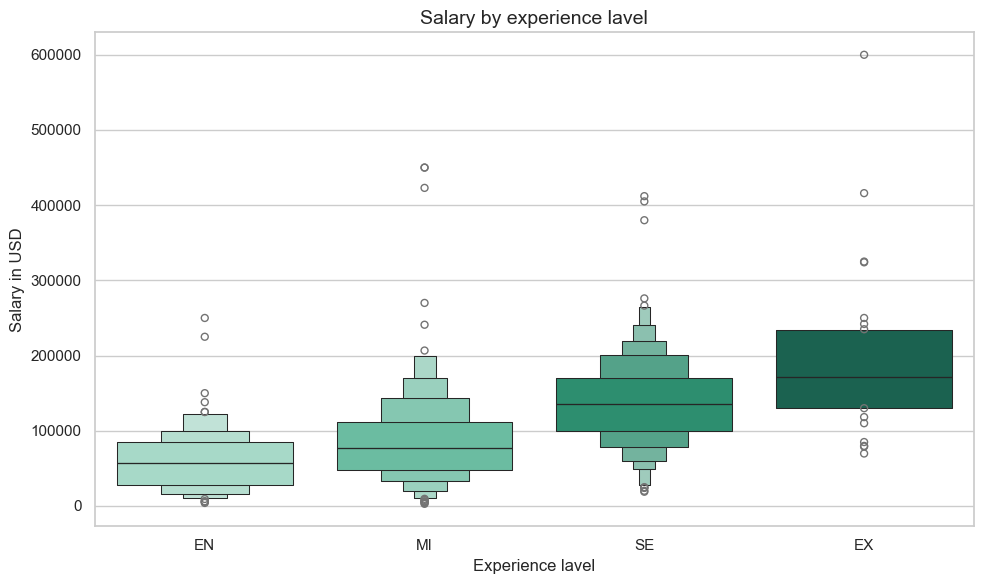

In [40]:
fig, ax=plt.subplots(figsize = (10,6))
sns.boxenplot(
    data=clean_df, x="experience_level", y="salary_in_usd",
    order=["EN", "MI", "SE", "EX"],
    palette=["#9FE1CB", "#5DCAA5", "#1D9E75", "#0F6E56"],
    ax=ax
)

ax.set_title("Salary by experience lavel")
ax.set_xlabel("Experience lavel")
ax.set_ylabel("Salary in USD")

plt.tight_layout()
plt.show()

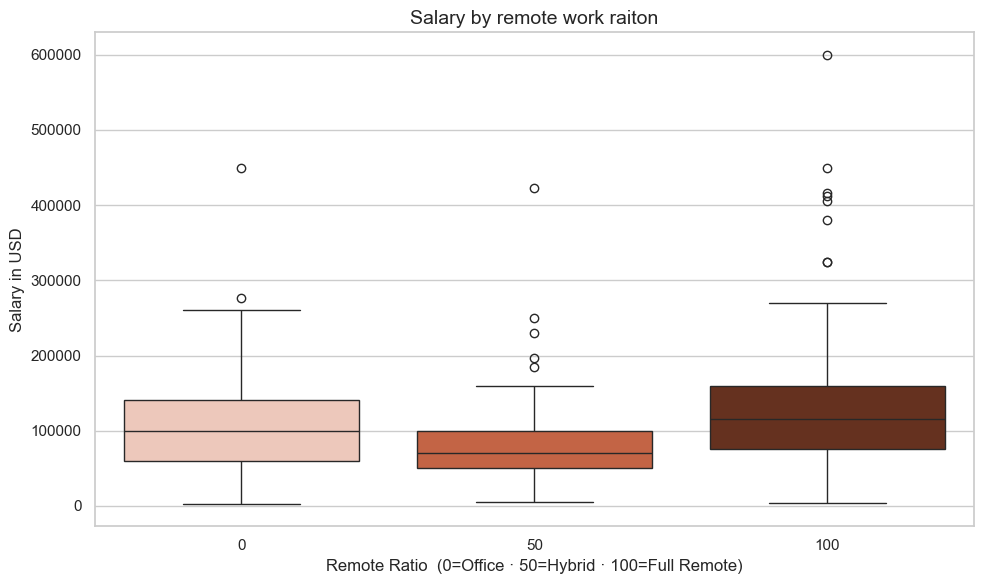

In [41]:
fig, ax = plt.subplots(figsize = (10,6))
sns.boxplot(
    data=clean_df,
    x="remote_ratio", y="salary_in_usd",
    palette=["#F5C4B3", "#D85A30", "#712B13"],
    ax=ax
)

ax.set_title("Salary by remote work raiton")
ax.set_xlabel("Remote Ratio  (0=Office · 50=Hybrid · 100=Full Remote)")
ax.set_ylabel("Salary in USD")

plt.tight_layout()
plt.show()

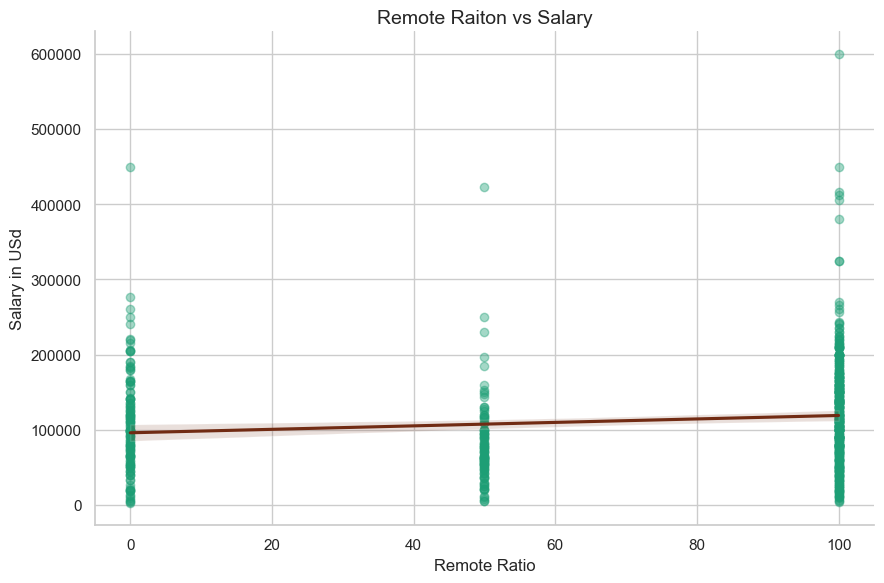

In [43]:
sns.lmplot(
    data=clean_df, 
    x="remote_ratio", y="salary_in_usd",
    height=6, aspect=1.5, 
    scatter_kws={"alpha": 0.4, "color": "#1D9E75"},
    line_kws={"color": "#712B13"}
)

plt.title("Remote Raiton vs Salary")
plt.xlabel("Remote Ratio")
plt.ylabel("Salary in USd")

plt.tight_layout()
plt.show()

In [56]:
top_jobs = (
    clean_df.groupby("job_title")["salary_in_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top_jobs = top_jobs.reset_index()
top_jobs.columns = ["job_title","avg_salary"]
print(top_jobs)
top_jobs.columns
top_jobs["job_title"] = top_jobs["job_title"].astype(str)

                  job_title     avg_salary
0       Data Analytics Lead  405000.000000
1   Principal Data Engineer  328333.333333
2    Financial Data Analyst  275000.000000
3  Principal Data Scientist  215242.428571
4  Director of Data Science  195074.000000
5            Data Architect  177873.909091
6    Applied Data Scientist  175655.000000
7        Analytics Engineer  175000.000000
8           Data Specialist  165000.000000
9              Head of Data  160162.600000


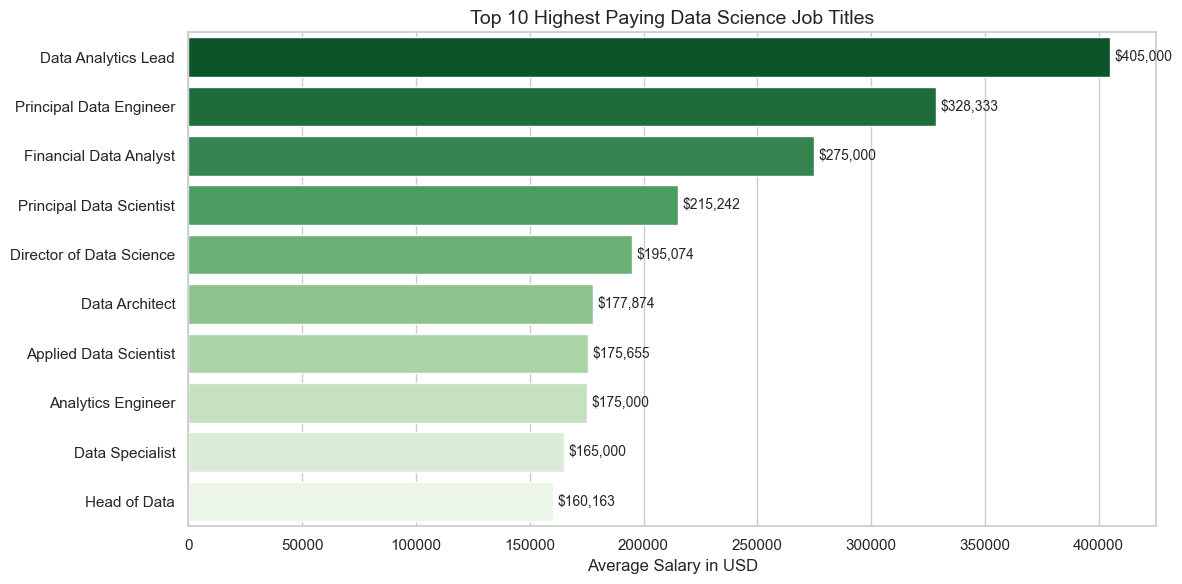

In [58]:

fig, ax=plt.subplots(figsize=(12,6))
sns.barplot(
    data=top_jobs,
    x="avg_salary", y="job_title",
    palette="Greens_r",
    ax=ax
)

ax.set_title("Top 10 Highest Paying Data Science Job Titles")
ax.set_xlabel("Average Salary in USD")
ax.set_ylabel("")

for i, v in enumerate(top_jobs["avg_salary"]):
    ax.text(v + 2000, i, f"${v:,.0f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

### Phase 5 — Encoding
> Convert categorical columns to numbers so ML models can read them.

In [59]:
encoded_df = pd.get_dummies(clean_df, drop_first=True, dtype=int)
print("Before encoding", clean_df.shape)
print("After encoding", encoded_df.shape)
encoded_df.head()

Before encoding (607, 9)
After encoding (607, 165)


,work_year,salary_in_usd,remote_ratio,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_FL,employment_type_FT,employment_type_PT,job_title_AI Scientist,...,company_location_RO,company_location_RU,company_location_SG,company_location_SI,company_location_TR,company_location_UA,company_location_US,company_location_VN,company_size_M,company_size_S
0,2020,79833,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020,260000,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2020,109024,50,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
3,2020,20000,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2020,150000,50,0,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


In [60]:
encoded_df.to_csv("../data/encoded_ds_salaries.csv", index=False)